# Extreme Rainfall Risk Classification - Data Preprocessing

## Preprocessing goals
- inspect dataset structure and quality
- handle duplicates and missing values
- convert datetime fields
- engineer useful weather features
- create the target variable `rainfall_class`
- avoid **data leakage**
- encode categorical features
- save a clean processed dataset for the model notebooks

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. Load the dataset

In [3]:
file_path = "../data/raw/SriLanka_Weather_Dataset.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (147480, 24)

Columns:
['time', 'weathercode', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'sunrise', 'sunset', 'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max', 'winddirection_10m_dominant', 'et0_fao_evapotranspiration', 'latitude', 'longitude', 'elevation', 'country', 'city']


,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,shortwave_radiation_sum,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,country,city
0,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,20.92,0.0,0.0,0.0,0.0,11.7,27.4,20,4.58,7.0,79.899994,16.0,Sri Lanka,Colombo
1,2010-01-02,51,29.9,23.5,26.2,33.8,26.2,29.8,2010-01-02T00:52,2010-01-02T12:36,17.71,0.1,0.1,0.0,1.0,13.0,27.0,24,3.84,7.0,79.899994,16.0,Sri Lanka,Colombo
2,2010-01-03,51,29.5,23.2,26.0,34.3,26.3,29.9,2010-01-03T00:53,2010-01-03T12:36,17.76,0.6,0.6,0.0,3.0,12.3,27.4,16,3.65,7.0,79.899994,16.0,Sri Lanka,Colombo
3,2010-01-04,2,28.9,21.9,25.3,31.6,23.4,27.8,2010-01-04T00:53,2010-01-04T12:37,16.50,0.0,0.0,0.0,0.0,17.0,34.6,356,3.79,7.0,79.899994,16.0,Sri Lanka,Colombo
4,2010-01-05,1,28.1,21.3,24.5,30.1,23.1,26.1,2010-01-05T00:53,2010-01-05T12:37,23.61,0.0,0.0,0.0,0.0,18.7,37.1,355,4.97,7.0,79.899994,16.0,Sri Lanka,Colombo


## 2. Initial inspection

In [4]:
print("Data types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique cities:", df["city"].nunique())
print("Countries:", df["country"].unique())

Data types:

time                           object
weathercode                     int64
temperature_2m_max            float64
temperature_2m_min            float64
temperature_2m_mean           float64
apparent_temperature_max      float64
apparent_temperature_min      float64
apparent_temperature_mean     float64
sunrise                        object
sunset                         object
shortwave_radiation_sum       float64
precipitation_sum             float64
rain_sum                      float64
snowfall_sum                  float64
precipitation_hours           float64
windspeed_10m_max             float64
windgusts_10m_max             float64
winddirection_10m_dominant      int64
et0_fao_evapotranspiration    float64
latitude                      float64
longitude                     float64
elevation                     float64
country                        object
city                           object
dtype: object

Missing values:

time                          0
weathercode

## 3. Remove duplicate rows

In [5]:
df = df.drop_duplicates().copy()
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (147480, 24)


## 4. Convert datetime columns

The dataset contains:
- `time`
- `sunrise`
- `sunset`

We convert them into datetime format and create useful time-based features.


In [6]:
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["sunrise"] = pd.to_datetime(df["sunrise"], errors="coerce")
df["sunset"] = pd.to_datetime(df["sunset"], errors="coerce")

print(df[["time", "sunrise", "sunset"]].head())

        time             sunrise              sunset
0 2010-01-01 2010-01-01 00:52:00 2010-01-01 12:35:00
1 2010-01-02 2010-01-02 00:52:00 2010-01-02 12:36:00
2 2010-01-03 2010-01-03 00:53:00 2010-01-03 12:36:00
3 2010-01-04 2010-01-04 00:53:00 2010-01-04 12:37:00
4 2010-01-05 2010-01-05 00:53:00 2010-01-05 12:37:00


## 5. Feature engineering

### 5.1 Calendar features
- year
- month
- day
- day of week
- quarter
- weekend flag

### 5.2 Daylight feature
- day length in hours from sunrise and sunset

### 5.3 Circular wind direction features
Wind direction is cyclic.  
So instead of using only the raw angle, we create:
- `wind_dir_sin`
- `wind_dir_cos`


In [7]:
# calendar features
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["day_of_week"] = df["time"].dt.dayofweek
df["quarter"] = df["time"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# day length
df["day_length_hours"] = (df["sunset"] - df["sunrise"]).dt.total_seconds() / 3600

# cyclic month encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# cyclic wind direction encoding
df["wind_dir_sin"] = np.sin(2 * np.pi * df["winddirection_10m_dominant"] / 360)
df["wind_dir_cos"] = np.cos(2 * np.pi * df["winddirection_10m_dominant"] / 360)

df[[
    "year", "month", "day", "day_of_week", "quarter", "is_weekend",
    "day_length_hours", "month_sin", "month_cos", "wind_dir_sin", "wind_dir_cos"
]].head()

,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos
0,2010,1,1,4,1,0,11.716667,0.5,0.866025,0.342020,0.939693
1,2010,1,2,5,1,1,11.733333,0.5,0.866025,0.406737,0.913545
2,2010,1,3,6,1,1,11.716667,0.5,0.866025,0.275637,0.961262
3,2010,1,4,0,1,0,11.733333,0.5,0.866025,-0.069756,0.997564
4,2010,1,5,1,1,0,11.733333,0.5,0.866025,-0.087156,0.996195


## 6. Create the target variable

We transform `rain_sum` into 4 rainfall intensity classes:

- **No Rain** = `rain_sum = 0`
- **Light Rain** = `0 < rain_sum < 5`
- **Moderate Rain** = `5 <= rain_sum < 20`
- **Heavy Rain** = `rain_sum >= 20`

This makes the problem a **multi-class classification** task.


rainfall_class
Light Rain       69341
Moderate Rain    42063
No Rain          26727
Heavy Rain        9349
Name: count, dtype: int64


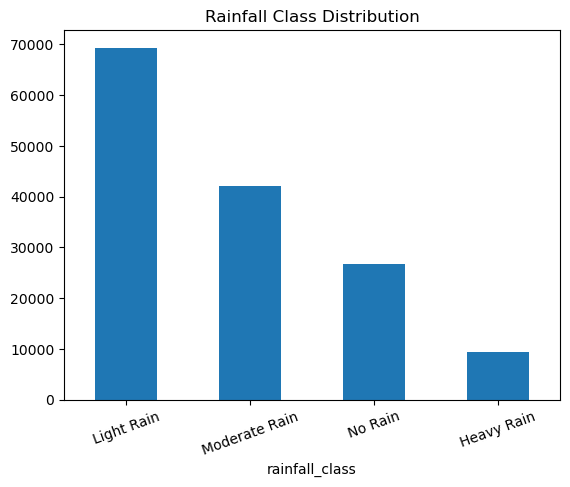

In [8]:
def classify_rain(x):
    if x == 0:
        return "No Rain"
    elif x < 5:
        return "Light Rain"
    elif x < 20:
        return "Moderate Rain"
    else:
        return "Heavy Rain"

df["rainfall_class"] = df["rain_sum"].apply(classify_rain)

print(df["rainfall_class"].value_counts())
df["rainfall_class"].value_counts().plot(kind="bar", title="Rainfall Class Distribution", rot=20)
plt.show()

## 7. Handle missing values

For this dataset:
- numeric columns → impute with **median**
- categorical columns → impute with **most frequent**

Median is a strong and safe choice for weather-related numerical features because it is less sensitive to outliers than mean.


In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# we do not treat target as a regular feature
if "rainfall_class" in categorical_cols:
    categorical_cols.remove("rainfall_class")

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


## 8. Remove leakage and low-value columns

### Leakage columns removed
These columns can directly reveal or strongly overlap with the target:
- `rain_sum`
- `precipitation_sum`

### Other columns removed
- `snowfall_sum` → usually zero / low relevance for Sri Lanka
- `time`, `sunrise`, `sunset` → raw datetime columns already converted into engineered features
- `country` → constant value (`Sri Lanka`) so it adds no predictive value
- `winddirection_10m_dominant` → replaced by cyclic sin/cos features
- `latitude`, `longitude` → optional; can keep, but here we remove them because `city` already captures location and avoids redundancy


In [10]:
columns_to_drop = [
    "rain_sum",
    "precipitation_sum",
    "snowfall_sum",
    "time",
    "sunrise",
    "sunset",
    "country",
    "winddirection_10m_dominant",
    "latitude",
    "longitude"
]

df_clean = df.drop(columns=columns_to_drop, errors="ignore").copy()

print("Shape after column removal:", df_clean.shape)
print(df_clean.columns.tolist())

Shape after column removal: (147480, 26)
['weathercode', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'shortwave_radiation_sum', 'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max', 'et0_fao_evapotranspiration', 'elevation', 'city', 'year', 'month', 'day', 'day_of_week', 'quarter', 'is_weekend', 'day_length_hours', 'month_sin', 'month_cos', 'wind_dir_sin', 'wind_dir_cos', 'rainfall_class']


## 9. Encode categorical columns

For the model notebooks, we save:
1. a **clean dataset** with readable labels
2. an **encoded dataset** ready for machine learning

Categorical feature:- `city` and Target: - `rainfall_class`


In [11]:
# Save clean dataset
clean_output_path = "../data/processed/sri_lanka_weather_processed.csv"
df_clean.to_csv(clean_output_path, index=False)

# Encode target
label_encoder = LabelEncoder()
df_encoded = df_clean.copy()
df_encoded["rainfall_class_encoded"] = label_encoder.fit_transform(df_encoded["rainfall_class"])

# One-hot encode city
df_encoded = pd.get_dummies(df_encoded, columns=["city"], drop_first=False)

# Save encoded dataset
encoded_output_path = "../data/processed/sri_lanka_weather_encoded.csv"
df_encoded.to_csv(encoded_output_path, index=False)

# Print outputs
print("Saved:", clean_output_path)
print("Saved:", encoded_output_path)

print("\nTarget classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

df_encoded.head()

Saved: ../data/processed/sri_lanka_weather_processed.csv
Saved: ../data/processed/sri_lanka_weather_encoded.csv

Target classes:
0 -> Heavy Rain
1 -> Light Rain
2 -> Moderate Rain
3 -> No Rain


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 10. Final check

In [12]:
print("Final clean dataset shape:", df_clean.shape)
print("Final encoded dataset shape:", df_encoded.shape)

print("\nClass distribution:")
print(df_clean["rainfall_class"].value_counts(normalize=True).round(4))

Final clean dataset shape: (147480, 26)
Final encoded dataset shape: (147480, 56)

Class distribution:
rainfall_class
Light Rain       0.4702
Moderate Rain    0.2852
No Rain          0.1812
Heavy Rain       0.0634
Name: proportion, dtype: float64
